# Phylum and Class Distribution

This notebook summarizes how the records in `dataset.csv` are distributed across the `taxon_phylum` and `taxon_class` labels and quantifies their frequencies.

In [408]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

dataset_path = None
for candidate in (
    Path('dataset.csv'),
    Path('EDA/dataset.csv'),
):
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError('dataset.csv not found; run the phylum sampling cell first.')

df = pd.read_csv(dataset_path, low_memory=False)

print(
    f'Read {len(df):,} rows and {len(df.columns)} columns from {dataset_path}.',
)

# def load_data(datafile):
#     dataset_path = None
#     for candidate in (
#         Path(datafile),
#     ):
#         if candidate.exists():
#             dataset_path = candidate
#             break
#     if dataset_path is None:
#         raise FileNotFoundError(f'{datafile} not found; run the phylum sampling cell first.')
    
#     df = pd.read_csv(dataset_path, low_memory=False)
    
#     print(
#         f'Read {len(df):,} rows and {len(df.columns)} columns from {dataset_path}.',
#     )
#     return df

# load_data('dataset.csv')

df.columns = df.columns.str.replace('_name$', '', regex=True)

df.head(3)
df.info()

Read 10,330 rows and 71 columns from dataset.csv.
<class 'pandas.DataFrame'>
RangeIndex: 10330 entries, 0 to 10329
Data columns (total 71 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   id                                                           10330 non-null  int64  
 1   uuid                                                         10330 non-null  str    
 2   observed_on_string                                           10329 non-null  str    
 3   observed_on                                                  10329 non-null  str    
 4   time_observed_at                                             9746 non-null   str    
 5   time_zone                                                    10330 non-null  str    
 6   user_id                                                      10330 non-null  int64  
 7   user_login                           

## Phylum counts

Compute the number and percentage of observations that fall into each phylum.

In [409]:
phylum_counts = (
    df['taxon_phylum']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'phylum'})
)
phylum_counts['percent'] = 100 * phylum_counts['count'] / len(df)
phylum_counts

,taxon_phylum,count,percent
0,Arthropoda,4717,45.663117
1,Chordata,3811,36.892546
2,Tracheophyta,1496,14.482091
3,Mollusca,94,0.909971
4,Basidiomycota,34,0.329138
5,Annelida,33,0.319458
6,Ascomycota,31,0.300097
7,Echinodermata,30,0.290416
8,Onychophora,23,0.222652
9,Unknown,21,0.203291


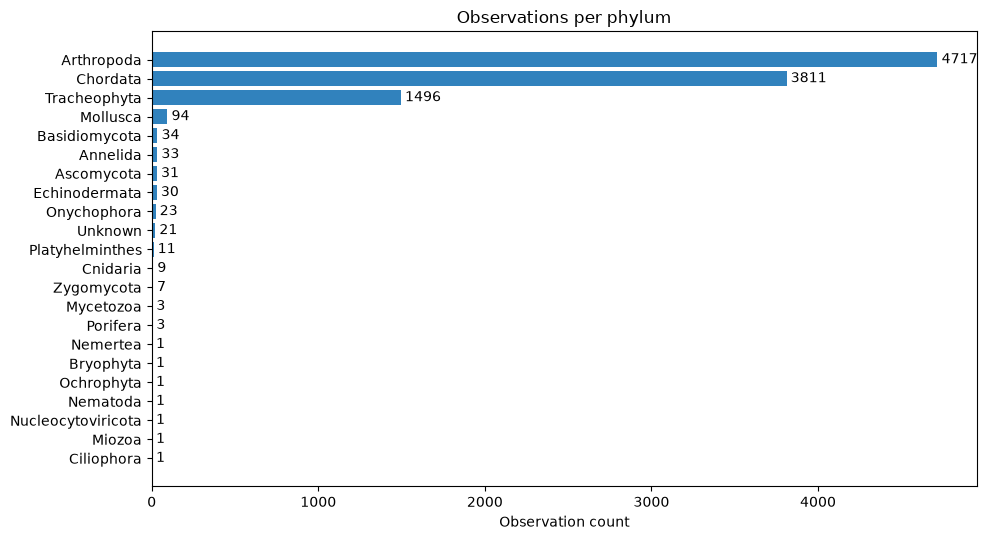

In [410]:
fig, ax = plt.subplots(figsize=(10, max(4, len(phylum_counts) * 0.25)))
bars = ax.barh(phylum_counts['taxon_phylum'], phylum_counts['count'], color='#3182bd')
ax.set_xlabel('Observation count')
ax.set_title('Observations per phylum')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

## Class counts

Repeat the same analysis for the `taxon_class` values.

In [411]:
class_counts = (
    df['taxon_class']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'taxon_class'})
)
class_counts['percent'] = 100 * class_counts['count'] / len(df)
class_counts

,taxon_class,count,percent
0,Insecta,3685,35.672798
1,Aves,2308,22.342691
2,Magnoliopsida,1319,12.768635
3,Arachnida,866,8.383349
4,Mammalia,499,4.830591
5,Reptilia,496,4.801549
6,Actinopterygii,360,3.484995
7,Liliopsida,147,1.423040
8,Amphibia,130,1.258470
9,Malacostraca,100,0.968054


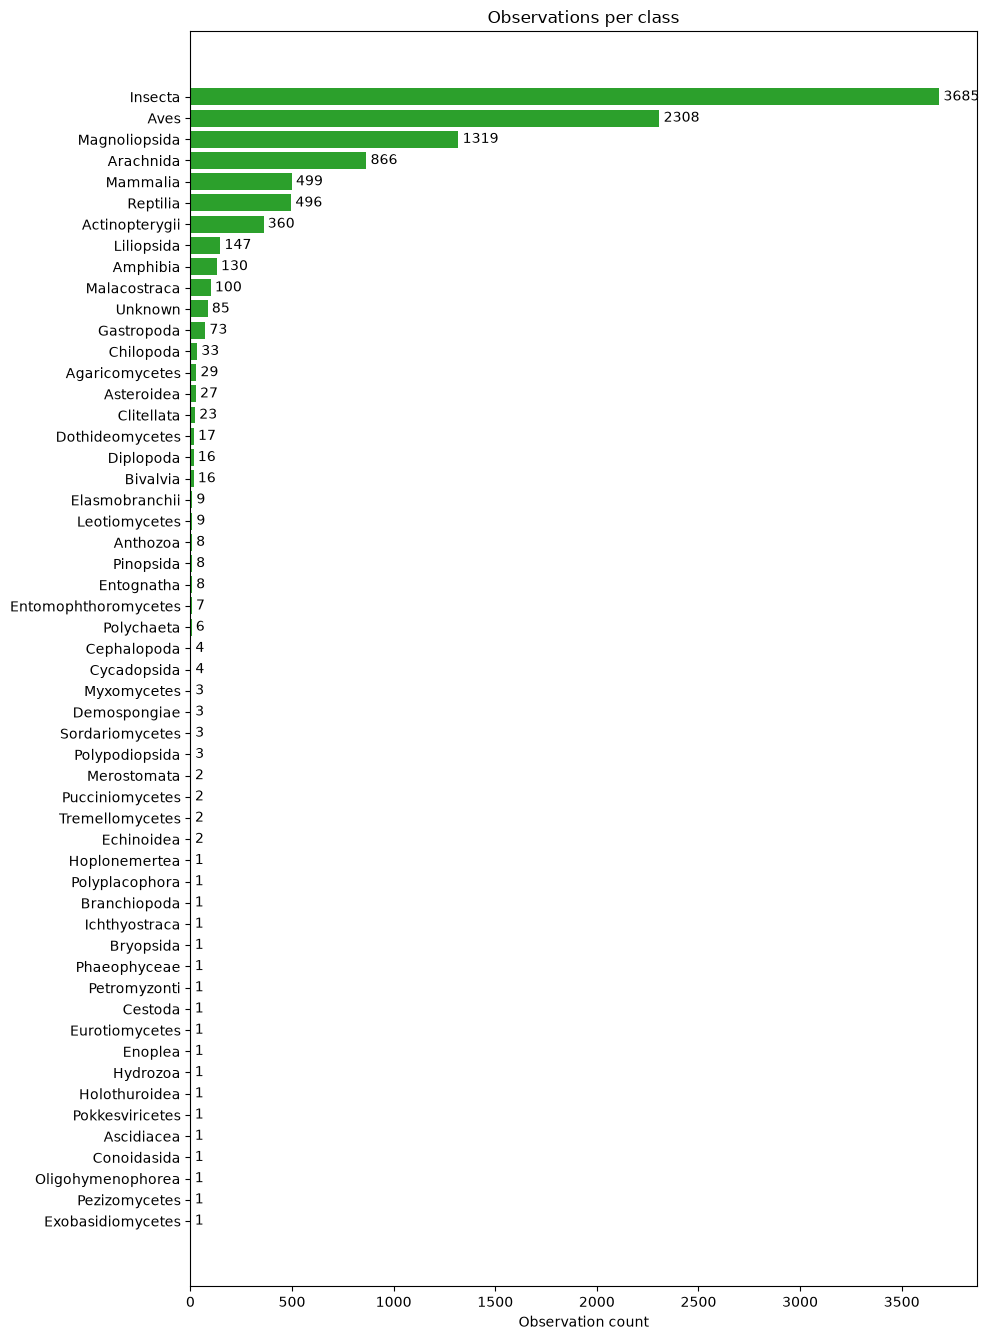

In [412]:
fig, ax = plt.subplots(figsize=(10, max(4, len(class_counts) * 0.25)))
bars = ax.barh(class_counts['taxon_class'], class_counts['count'], color='#2ca02c')
ax.set_xlabel('Observation count')
ax.set_title('Observations per class')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

## Chordata diversity samples

Find up to seven observations from the Chordata phylum that each have a unique combination of class, order, family, and genus.

In [413]:
from pathlib import Path
phylum_cols = ['taxon_class', 'taxon_order', 'taxon_family', 'taxon_genus']
sample = []
for phylum in sorted(df['taxon_phylum'].dropna().unique()):
    phylum_df = df[df['taxon_phylum'] == phylum] 
    phylum_unique = (
        phylum_df
        .drop_duplicates(subset=phylum_cols)
        .head(21)
        .reset_index(drop=True)
    )
    sample.append(phylum_unique)
    print(
        f"Showing {len(phylum_unique)} {phylum} entries with distinct class/order/family/genus combos (up to 21)."
    )
sample_df = pd.concat(sample, ignore_index=True)
output_path = Path('sample_3x.csv')
output_path.parent.mkdir(exist_ok=True)



Showing 11 Annelida entries with distinct class/order/family/genus combos (up to 21).
Showing 21 Arthropoda entries with distinct class/order/family/genus combos (up to 21).
Showing 15 Ascomycota entries with distinct class/order/family/genus combos (up to 21).
Showing 21 Basidiomycota entries with distinct class/order/family/genus combos (up to 21).
Showing 1 Bryophyta entries with distinct class/order/family/genus combos (up to 21).
Showing 21 Chordata entries with distinct class/order/family/genus combos (up to 21).
Showing 1 Ciliophora entries with distinct class/order/family/genus combos (up to 21).
Showing 4 Cnidaria entries with distinct class/order/family/genus combos (up to 21).
Showing 7 Echinodermata entries with distinct class/order/family/genus combos (up to 21).
Showing 1 Miozoa entries with distinct class/order/family/genus combos (up to 21).
Showing 21 Mollusca entries with distinct class/order/family/genus combos (up to 21).
Showing 3 Mycetozoa entries with distinct cl

In [414]:
# standardize column headers to match phylum_sample.csv from BioVerify
keep_cols = [
    "id", "url",  "image_url", "scientific", "common",
    "quality_grade", "uri", "taxon_kingdom", "taxon_phylum", 
    "taxon_class", "taxon_order", "taxon_family", "taxon_genus", "taxon_species"
]
sample_df = sample_df[[c for c in keep_cols if c in sample_df.columns]]

sample_df["photo_id"] = sample_df["image_url"].str.extract(r"/photos/(\d+)", expand=False)
sample_df = sample_df.rename(columns={
    "id":        "observation_id",     
    "url":       "uri",              
    "image_url": "medium_url",       
    "scientific": "scientific_name",
    "common": "common_name"
})
sample_df["Image_name"] = (
    "obs_" + sample_df["observation_id"].astype(str) + "_photo_" + sample_df["photo_id"].astype(str)
)

column_order = [
    "observation_id",
    "photo_id",
    "Image_name",    
    "medium_url",
    "scientific_name", 
    "common_name", 
    "quality_grade",
    "uri",
    "taxon_kingdom",
    "taxon_phylum",
    "taxon_class",
    "taxon_order",
    "taxon_family",
    "taxon_genus",
    "taxon_species"
]
sample_df = sample_df[[c for c in column_order if c in sample_df.columns]]

sample_df.to_csv(output_path, index=False)



## Sample 1x Distribution

In [415]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# load_data('sample_1x.csv')
dataset_path = None
for candidate in (
    Path('sample_1x.csv'),
):
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError('outputs/sample_1x.csv not found; run the phylum sampling cell first.')

df = pd.read_csv(dataset_path)

print(
    f'Read {len(df):,} rows and {len(df.columns)} columns from {dataset_path}.',
)
df.head(3)

Read 63 rows and 31 columns from sample.csv.


,observation_id,photo_id,Image_name,GroundingDino_V.1_Detected?,V.1 Analysis,GroundingDino_V.2_Detected?,V.2 Analysis,license_code,sam2+bioclip classification v.3,v3. Analysis,...,uri,pred_prey,special_type_of_feeding,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,102691691,171703626,obs_102691691_photo_171703626,Maybe,Tiny part of the box,Yes,Visible,cc-by-nc,True,NaN,...,https://www.inaturalist.org/observations/10269...,Prey,Predation,Chromista,Ochrophyta,Phaeophyceae,Laminariales,Lessoniaceae,Egregia,Egregia menziesii
1,10317797,14298032,obs_10317797_photo_14298032,Maybe,Tiny part of the box,Yes,Visible,cc-by-nc,False,Prey and predator both in the picture. Leather...,...,https://www.inaturalist.org/observations/10317797,Prey,Predation,Animalia,Echinodermata,Asteroidea,Valvatida,Asteropseidae,Dermasterias,Dermasterias imbricata
2,130480768,70327211,obs_130480768_photo_70327211,Maybe,Tiny part of the box,Yes,Visible,cc-by,False,NaN,...,https://www.inaturalist.org/observations/13048...,Pred,Parasitism,Animalia,Annelida,Clitellata,Arhynchobdellida,Hirudinidae,Hirudo,Hirudo michaelseni


In [416]:
phylum_counts = (
    df['taxon_phylum']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'phylum'})
)
phylum_counts['percent'] = 100 * phylum_counts['count'] / len(df)
phylum_counts

,taxon_phylum,count,percent
0,Basidiomycota,7,11.111111
1,Ascomycota,7,11.111111
2,Echinodermata,6,9.523810
3,Mollusca,6,9.523810
4,Tracheophyta,6,9.523810
5,Arthropoda,6,9.523810
6,Chordata,6,9.523810
7,Annelida,3,4.761905
8,Platyhelminthes,3,4.761905
9,Onychophora,3,4.761905


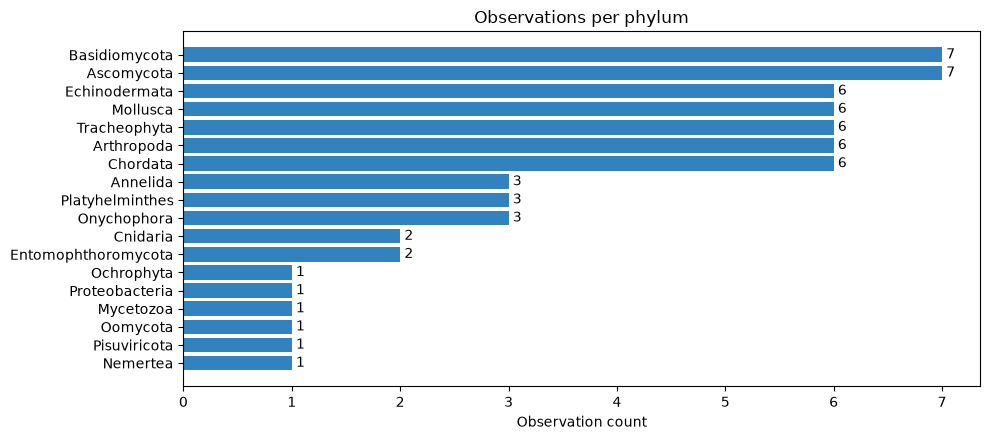

In [417]:
fig, ax = plt.subplots(figsize=(10, max(4, len(phylum_counts) * 0.25)))
bars = ax.barh(phylum_counts['taxon_phylum'], phylum_counts['count'], color='#3182bd')
ax.set_xlabel('Observation count')
ax.set_title('Observations per phylum')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

In [418]:
class_counts = (
    df['taxon_class']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'taxon_class'})
)
class_counts['percent'] = 100 * class_counts['count'] / len(df)
class_counts

,taxon_class,count,percent
0,0,6,9.523810
1,Magnoliopsida,6,9.523810
2,Insecta,6,9.523810
3,Agaricomycetes,4,6.349206
4,Gastropoda,4,6.349206
5,Aves,4,6.349206
6,Asteroidea,3,4.761905
7,Pucciniomycetes,3,4.761905
8,Dothideomycetes,3,4.761905
9,Leotiomycetes,3,4.761905


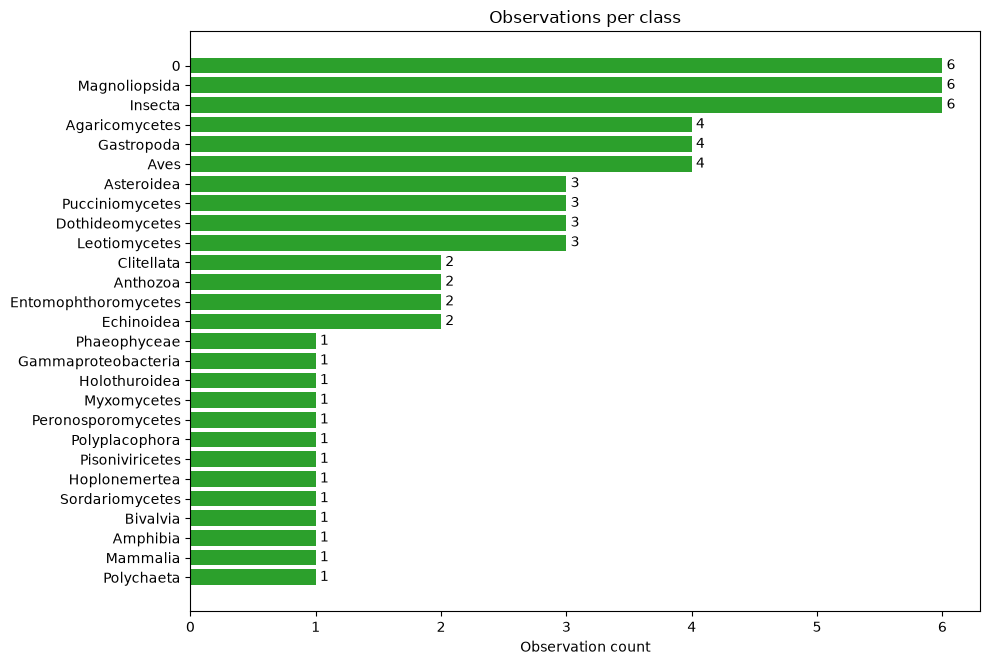

In [419]:
fig, ax = plt.subplots(figsize=(10, max(4, len(class_counts) * 0.25)))
bars = ax.barh(class_counts['taxon_class'], class_counts['count'], color='#2ca02c')
ax.set_xlabel('Observation count')
ax.set_title('Observations per class')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

## Sample 3x Distribution

In [420]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# load_data('sample_3x.csv')
dataset_path = None
for candidate in (
    Path('sample_3x.csv'),
):
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError('outputs/sample_3x.csv not found; run the phylum sampling cell first.')

df = pd.read_csv(dataset_path)

print(
    f'Read {len(df):,} rows and {len(df.columns)} columns from {dataset_path}.',
)
df.head(3)

Read 167 rows and 15 columns from sample_3x.csv.


,observation_id,photo_id,Image_name,medium_url,scientific_name,common_name,quality_grade,uri,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,33435757,52514997,obs_33435757_photo_52514997,https://inaturalist-open-data.s3.amazonaws.com...,Nereididae,Ragworms and Allies,needs_id,https://www.inaturalist.org/observations/33435757,Animalia,Annelida,Polychaeta,Phyllodocida,Nereididae,NaN,NaN
1,54130547,86113964,obs_54130547_photo_86113964,https://inaturalist-open-data.s3.amazonaws.com...,Lumbricidae,Lumbricid Earthworms,needs_id,https://www.inaturalist.org/observations/54130547,Animalia,Annelida,Clitellata,Crassiclitellata,Lumbricidae,NaN,NaN
2,55364509,88154142,obs_55364509_photo_88154142,https://inaturalist-open-data.s3.amazonaws.com...,Haemadipsa trimaculosa,NaN,needs_id,https://www.inaturalist.org/observations/55364509,Animalia,Annelida,Clitellata,Arhynchobdellida,Haemadipsidae,Haemadipsa,Haemadipsa trimaculosa


In [421]:
phylum_counts = (
    df['taxon_phylum']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'phylum'})
)
phylum_counts['percent'] = 100 * phylum_counts['count'] / len(df)
phylum_counts

,taxon_phylum,count,percent
0,Arthropoda,21,12.574850
1,Basidiomycota,21,12.574850
2,Chordata,21,12.574850
3,Mollusca,21,12.574850
4,Tracheophyta,21,12.574850
5,Ascomycota,15,8.982036
6,Annelida,11,6.586826
7,Echinodermata,7,4.191617
8,Onychophora,5,2.994012
9,Platyhelminthes,5,2.994012


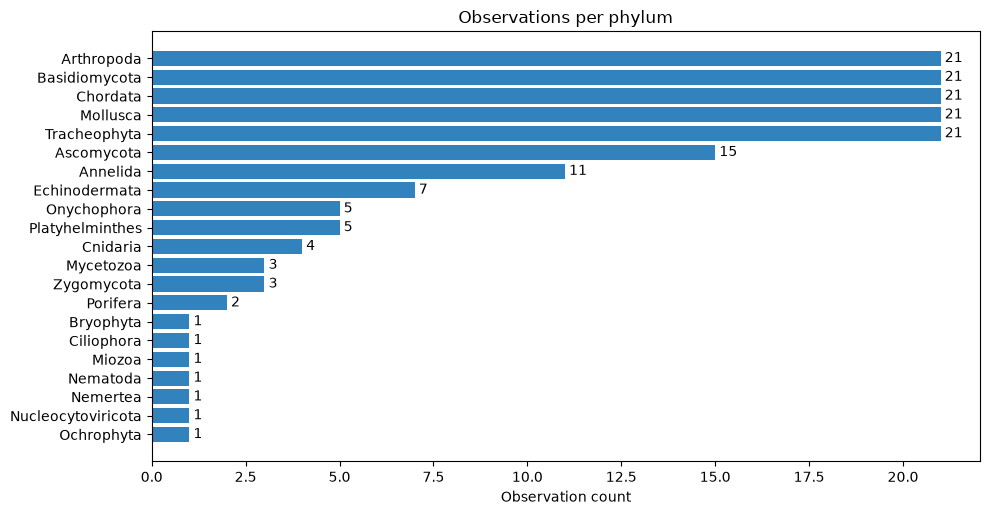

In [422]:
fig, ax = plt.subplots(figsize=(10, max(4, len(phylum_counts) * 0.25)))
bars = ax.barh(phylum_counts['taxon_phylum'], phylum_counts['count'], color='#3182bd')
ax.set_xlabel('Observation count')
ax.set_title('Observations per phylum')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig


In [423]:
class_counts = (
    df['taxon_class']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'taxon_class'})
)
class_counts['percent'] = 100 * class_counts['count'] / len(df)
class_counts

,taxon_class,count,percent
0,Insecta,20,11.976048
1,Agaricomycetes,20,11.976048
2,Magnoliopsida,17,10.179641
3,Gastropoda,15,8.982036
4,Unknown,10,5.988024
5,Mammalia,9,5.389222
6,Reptilia,8,4.790419
7,Clitellata,7,4.191617
8,Dothideomycetes,5,2.994012
9,Leotiomycetes,5,2.994012


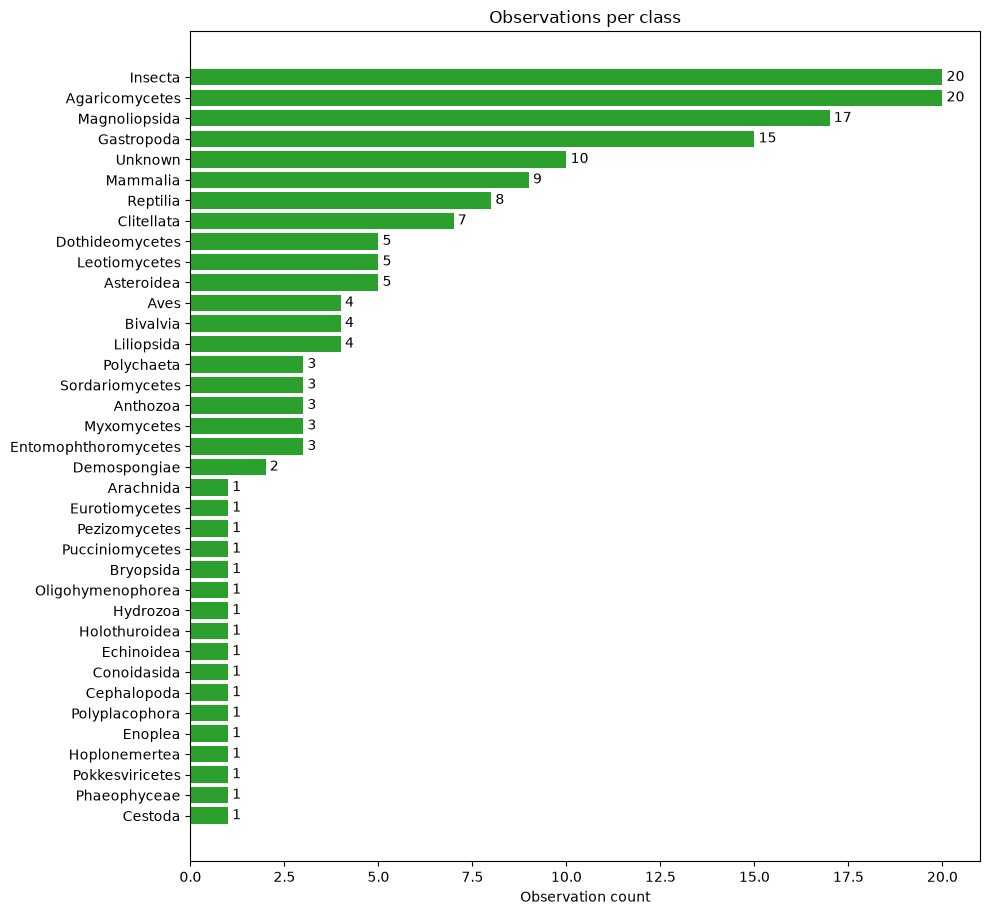

In [424]:
def class_chart():
    fig, ax = plt.subplots(figsize=(10, max(4, len(class_counts) * 0.25)))
    bars = ax.barh(class_counts['taxon_class'], class_counts['count'], color='#2ca02c')
    ax.set_xlabel('Observation count')
    ax.set_title('Observations per class')
    ax.invert_yaxis()
    ax.bar_label(bars, fmt='%d', padding=3)
    plt.tight_layout()

class_chart()
# fig